You are working with the government to transform your city into a smart city. The vision is to convert it into a digital and intelligent city to improve the efficiency of services for the citizens. One of the problems faced by the government is traffic. You are a data scientist working to manage the traffic of the city better and to provide input on infrastructure planning for the future.

The government wants to implement a robust traffic system for the city by being prepared for traffic peaks. They want to understand the traffic patterns of the four junctions of the city. Traffic patterns on holidays, as well as on various other occasions during the year, differ from normal working days. This is important to take into account for your forecasting.

To predict traffic patterns in each of these four junctions for the next 4 months.

The sensors on each of these junctions were collecting data at different times, hence you will see traffic data from different time periods. To add to the complexity, some of the junctions have provided limited or sparse data requiring thoughtfulness when creating future projections. Depending upon the historical data of 20 months, the government is looking to you to deliver accurate traffic projections for the coming four months. Your algorithm will become the foundation of a larger transformation to make your city smart and intelligent.


# Importar librerias

In [1]:
#importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Importar archivos csv 

In [84]:
#leer los archivos
#Leer el archivo de entrenamiento:
train = pd.read_csv('https://raw.githubusercontent.com/TracyRenee61/Traffic-Forecasting/main/train_aWnotuB.csv')
#Leer el archivo de prueba:
test = pd.read_csv('https://raw.githubusercontent.com/TracyRenee61/Traffic-Forecasting/main/test_BdBKkAj.csv')
#Leer el archivo de envío de muestras
sample = pd.read_csv('https://raw.githubusercontent.com/TracyRenee61/Traffic-Forecasting/main/sample_submission_EZmX9uE.csv')

In [85]:
train # Datos de entrenamiento

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041
...,...,...,...,...
48115,2017-06-30 19:00:00,4,11,20170630194
48116,2017-06-30 20:00:00,4,30,20170630204
48117,2017-06-30 21:00:00,4,16,20170630214
48118,2017-06-30 22:00:00,4,22,20170630224


In [86]:
test # Datos de Prueba

,DateTime,Junction,ID
0,2017-07-01 00:00:00,1,20170701001
1,2017-07-01 01:00:00,1,20170701011
2,2017-07-01 02:00:00,1,20170701021
3,2017-07-01 03:00:00,1,20170701031
4,2017-07-01 04:00:00,1,20170701041
...,...,...,...
11803,2017-10-31 19:00:00,4,20171031194
11804,2017-10-31 20:00:00,4,20171031204
11805,2017-10-31 21:00:00,4,20171031214
11806,2017-10-31 22:00:00,4,20171031224


In [87]:
sample #muestra

,ID,Vehicles


In [88]:
train.info() # información sobre los datos de entrenamiento

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [89]:
test.info() # información sobre los datos de prueba

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11808 entries, 0 to 11807
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  11808 non-null  object
 1   Junction  11808 non-null  int64 
 2   ID        11808 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 276.9+ KB


# Revisar si existen valores nulos

In [90]:
train.isnull().sum()

DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64

In [91]:
test.isnull().sum()

DateTime    0
Junction    0
ID          0
dtype: int64

# Convertir columna Datetime en año, mes, semana, dia y hora

In [92]:
train['DateTime'] = pd.to_datetime(train['DateTime'], errors='coerce')
test['DateTime'] = pd.to_datetime(test['DateTime'], errors='coerce')

train['hourofday'] = train['DateTime'].dt.hour
test['hourofday'] = test['DateTime'].dt.hour

train['dayofweek'] = train['DateTime'].dt.dayofweek
test['dayofweek'] = test['DateTime'].dt.dayofweek

train['weekofyear'] = train['DateTime'].dt.week
test['weekofyear'] = test['DateTime'].dt.week

train['monthofyear'] = train['DateTime'].dt.month
test['monthofyear'] = test['DateTime'].dt.month

train['year'] = train['DateTime'].dt.year
test['year'] = test['DateTime'].dt.year


C:\Users\valer\AppData\Local\Temp/ipykernel_16348/3017924218.py:10: FutureWarning: Series.dt.weekofyear and Series.dt.week have been deprecated.  Please use Series.dt.isocalendar().week instead.
  train['weekofyear'] = train['DateTime'].dt.week
C:\Users\valer\AppData\Local\Temp/ipykernel_16348/3017924218.py:11: FutureWarning: Series.dt.weekofyear and Series.dt.week have been deprecated.  Please use Series.dt.isocalendar().week instead.
  test['weekofyear'] = test['DateTime'].dt.week


# Preparar datos

In [93]:
ID_train = train.ID
ID_test = test.ID

In [94]:
train.drop(['ID'], axis=1, inplace=True)
test.drop(['ID'], axis=1, inplace=True)
test

,DateTime,Junction,hourofday,dayofweek,weekofyear,monthofyear,year
0,2017-07-01 00:00:00,1,0,5,26,7,2017
1,2017-07-01 01:00:00,1,1,5,26,7,2017
2,2017-07-01 02:00:00,1,2,5,26,7,2017
3,2017-07-01 03:00:00,1,3,5,26,7,2017
4,2017-07-01 04:00:00,1,4,5,26,7,2017
...,...,...,...,...,...,...,...
11803,2017-10-31 19:00:00,4,19,1,44,10,2017
11804,2017-10-31 20:00:00,4,20,1,44,10,2017
11805,2017-10-31 21:00:00,4,21,1,44,10,2017
11806,2017-10-31 22:00:00,4,22,1,44,10,2017


In [95]:
train

,DateTime,Junction,Vehicles,hourofday,dayofweek,weekofyear,monthofyear,year
0,2015-11-01 00:00:00,1,15,0,6,44,11,2015
1,2015-11-01 01:00:00,1,13,1,6,44,11,2015
2,2015-11-01 02:00:00,1,10,2,6,44,11,2015
3,2015-11-01 03:00:00,1,7,3,6,44,11,2015
4,2015-11-01 04:00:00,1,9,4,6,44,11,2015
...,...,...,...,...,...,...,...,...
48115,2017-06-30 19:00:00,4,11,19,4,26,6,2017
48116,2017-06-30 20:00:00,4,30,20,4,26,6,2017
48117,2017-06-30 21:00:00,4,16,21,4,26,6,2017
48118,2017-06-30 22:00:00,4,22,22,4,26,6,2017


# Convertir columnas a enteros

In [96]:
train.hourofday=train.hourofday.astype(int)
train.dayofweek=train.dayofweek.astype(int)
train.weekofyear=train.weekofyear.astype(int)
train.monthofyear=train.monthofyear.astype(int)
train.year=train.year.astype(int)

test.hourofday=test.hourofday.astype(int)
test.dayofweek=test.dayofweek.astype(int)
test.weekofyear=test.weekofyear.astype(int)
test.monthofyear=test.monthofyear.astype(int)
test.year=test.year.astype(int)


In [97]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   DateTime     48120 non-null  datetime64[ns]
 1   Junction     48120 non-null  int64         
 2   Vehicles     48120 non-null  int64         
 3   hourofday    48120 non-null  int32         
 4   dayofweek    48120 non-null  int32         
 5   weekofyear   48120 non-null  int32         
 6   monthofyear  48120 non-null  int32         
 7   year         48120 non-null  int32         
dtypes: datetime64[ns](1), int32(5), int64(2)
memory usage: 2.0 MB


In [16]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11808 entries, 0 to 11807
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   DateTime     11808 non-null  datetime64[ns]
 1   Junction     11808 non-null  int64         
 2   hourofday    11808 non-null  int32         
 3   dayofweek    11808 non-null  int32         
 4   weekofyear   11808 non-null  int32         
 5   monthofyear  11808 non-null  int32         
 6   year         11808 non-null  int32         
dtypes: datetime64[ns](1), int32(5), int64(1)
memory usage: 415.2 KB


# Graficar los datos

Text(0, 0.5, 'Vehicles')

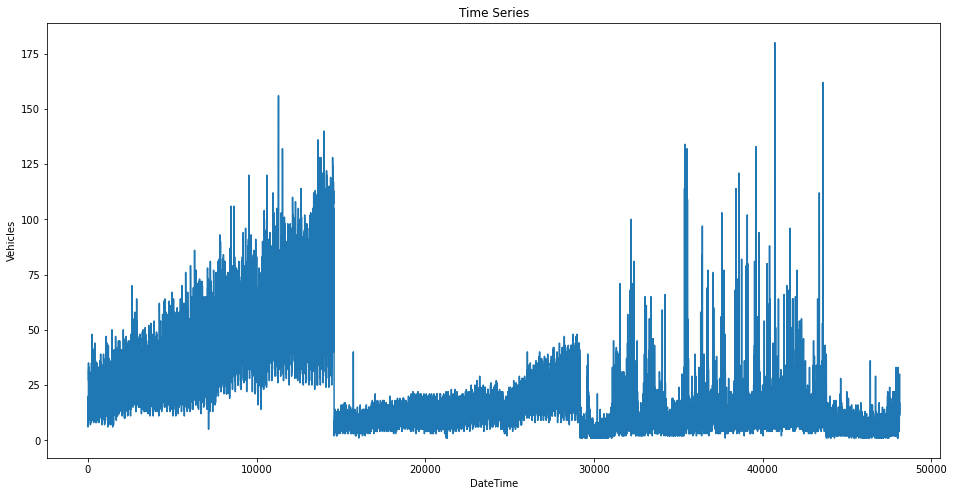

In [98]:
import matplotlib.pyplot as plt

train['Vehicles'].plot(figsize=(16, 8))
plt.title('Time Series') 
plt.xlabel("DateTime") 
plt.ylabel("Vehicles")

# Definir variables X y Y

In [109]:
y = train['Vehicles'].values
X = train.drop(['Vehicles', 'DateTime'], axis=1)
X_test = test.drop(['DateTime'], axis=1)

# Dividir el conjunto de entrenamiento para la prueba y la validación

In [121]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=1)
print(X_train.shape)
print(X_val.shape) 
print(y_train.shape)
print(y_val.shape)
print(X_test.shape)


(43308, 6)
(4812, 6)
(43308,)
(4812,)
(4812, 6)


# desicion tree classifier vs bagging y random forest

In [126]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

# Instantiate dt
dt = DecisionTreeClassifier(random_state=1)

# Instantiate bc
bc = BaggingClassifier(base_estimator=dt, n_estimators=50, random_state=1)

In [127]:
from sklearn.metrics import accuracy_score

# Fit bc to the training set
bc.fit(X_train, y_train)

# Predict test set labels
y_pred = bc.predict(X_val)

# Evaluate acc_test
acc_test = accuracy_score(y_val, y_pred)
print('Test set accuracy of bc: {:.2f}'.format(acc_test))

MemoryError: could not allocate 35913728 bytes

In [22]:
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_val)

acc_test_dt = accuracy_score(y_val, y_pred_dt)
print('Test set accuracy of dt: {:.2f}'.format(acc_test_dt))

Test set accuracy of dt: 0.11


In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

# Instantiate dt
dt = DecisionTreeClassifier(min_samples_leaf=8, random_state=1)

# Instantiate bc
bc = BaggingClassifier(base_estimator=dt, n_estimators=50, oob_score=True, random_state=1)

In [24]:
# Fit bc to the training set
bc.fit(X_train, y_train)

# Predict test set labels
y_pred = bc.predict(X_val)

# Evaluate test set accuracy
acc_test = accuracy_score(y_val, y_pred)

# Evaluate OOB accuracy
acc_oob = bc.oob_score_

# Print acc_test and acc_oob
print('Test set accuracy: {:.3f}, OOB accuracy: {:.3f}'.format(acc_test, acc_oob))

Test set accuracy: 0.131, OOB accuracy: 0.128


In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Instantiate dt
dt = DecisionTreeClassifier(random_state=1)

# Instantiate bc
rfc = RandomForestClassifier( n_estimators=50, random_state=1)

In [36]:
from sklearn.metrics import accuracy_score

# Fit bc to the training set
rfc.fit(X_train, y_train)

# Predict test set labels
y_pred11 = rfc.predict(X_val)

# Evaluate acc_test
acc_test = accuracy_score(y_val, y_pred11)
print('Test set accuracy of rfc: {:.2f}'.format(acc_test))

Test set accuracy of rfc: 0.11


In [37]:
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_val)

acc_test_dt = accuracy_score(y_val, y_pred_dt)
print('Test set accuracy of dt: {:.2f}'.format(acc_test_dt))

Test set accuracy of dt: 0.11


# RMSE para Random forest y bagging

In [68]:
from sklearn.ensemble import RandomForestRegressor

# Instantiate rf
rf = RandomForestRegressor(n_estimators=100, random_state=2)

# Fit rf to the training set
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=2)

In [69]:
from sklearn.metrics import mean_squared_error as MSE

# Predict the test set labels
y_pred = rf.predict(X_val)

# Evaluate the test set RMSE
rmse_test = MSE(y_val, y_pred) ** 0.5

# Print rmse_test
print('Test set RMSE of rf: {:.2f}'.format(rmse_test))

Test set RMSE of rf: 3.67


In [70]:
 from sklearn.ensemble import BaggingRegressor

# Instantiate br
br = BaggingRegressor(n_estimators=100, random_state=2)

# Fit br to the training set
br.fit(X_train, y_train)

BaggingRegressor(n_estimators=100, random_state=2)

In [71]:
from sklearn.metrics import mean_squared_error as MSE

# Predict the test set labels
y_pred1 = br.predict(X_val)

# Evaluate the test set RMSE
rmse_test1 = MSE(y_val, y_pred1) ** 0.5

# Print rmse_test
print('Test set RMSE of br: {:.2f}'.format(rmse_test1))

Test set RMSE of br: 3.68


# Hacer un  pipeline (conjunto de acciones)

In [102]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import GradientBoostingRegressor

model = make_pipeline(StandardScaler(), BaggingRegressor(base_estimator=GradientBoostingRegressor(max_depth=10, min_samples_split=2, loss='ls',n_estimators=400, learning_rate=.1, random_state=1))).fit(X_train, y_train)
print(model.score(X_train, y_train))

0.9907989657945035


# Predicción en el conjunto de validación

In [103]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_val)
y_pred = y_pred.astype(int)
print(model.score(X_val, y_val))# precision del conjunto
print(r2_score(y_pred, model.predict(X_val)))# coeficiente de determinacion R^2

0.9692592579270412
0.999203067845309


In [104]:
y_val

array([ 18, 107,  14, ...,   8,  49,  17], dtype=int64)

In [105]:
y_pred

array([ 20, 109,  15, ...,   7,  48,  16])

In [106]:
df_val=pd.DataFrame({'actual': y_val, 'predicted': y_pred})
df_val.reset_index(drop=True, inplace=True)
df_val

,actual,predicted
0,18,20
1,107,109
2,14,15
3,18,20
4,11,23
...,...,...
4807,4,7
4808,46,46
4809,8,7
4810,49,48


# Graficar predicciones 

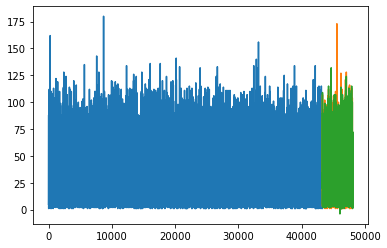

In [111]:
# Graficar las predicciones y los resultados esperados
from matplotlib import pyplot

pyplot.plot(y_train)
pyplot.plot([None for i in y_train] + [x for x in y_val])# naranja valor actual
pyplot.plot([None for i in y_train] + [y for y in y_pred])#verde valor predecido
pyplot.show()

# Predicción en el conjunto de pruebas

In [112]:
final_labels = model.predict(X_test)
final_labels = final_labels.astype(int)
final_labels

array([68, 57, 47, ...,  8,  8,  7])

In [113]:
output = pd.DataFrame({'ID': ID_test, 'Vehicles': final_labels})
output.to_csv('submission.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!


In [26]:
#upload submission
submission = pd.read_csv("submission.csv")
submission

,ID,Vehicles
0,20170701001,67
1,20170701011,55
2,20170701021,48
3,20170701031,40
4,20170701041,34
...,...,...
11803,20171031194,10
11804,20171031204,8
11805,20171031214,8
11806,20171031224,7
